# 01. Data Preprocessing

**Pipeline goal.** Take parcel-level fMRI-like timeseries, project them onto a low-dimensional functional-connectivity (FC) gradient manifold, and reconstruct a 6-dimensional phase-space trajectory per subject and per condition. The output of this notebook is the input of `02_lyapunov_estimation.ipynb`.

**Original study.** The full study used:
- Schaefer-100 parcellation of resting-state fMRI under LSD, DMT, and placebo
- Group-mean HCP functional connectivity decomposed into 3 principal gradients (BrainSpace toolbox)
- Cross-condition comparison of trajectory stability

**This notebook.** All real data paths and toolbox calls (`brainspace`, `nilearn` maskers, HCP files) are replaced with a self-contained simulator that produces structurally analogous synthetic data. The downstream analysis code is identical to the real pipeline, so this notebook is fully reproducible without external dependencies and demonstrates the method end-to-end.

**Pipeline steps:**
1. Simulate parcel timeseries for 15 subjects in two conditions: `drug` and `pcb` (placebo). Drug condition has chaotic dynamics injected into the latent shared component (entropic-brain analogue).
2. Build mock FC gradients (3 components) via eigendecomposition of a synthetic FC matrix. In the real pipeline this is `brainspace.GradientMaps`.
3. Project each subject's parcel timeseries into 3D gradient space by per-timepoint Pearson correlation of the parcel pattern against each gradient. Output: $(T, 3)$ per subject.
4. Build 6D phase space by concatenating gradient correlations with their first time derivative: $X_t = [g_t, \dot g_t] \in \mathbb{R}^6$. Output: $(T-1, 6)$ per subject.
5. Save a single `phase_space.pkl` for the next notebook.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

sns.set_context("notebook")
sns.set_style("ticks")

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Pipeline parameters (match original study where applicable)
N_PARCELS = 100         # Schaefer-100
N_TR = 200              # post-resampling timeseries length
N_SUBJ = 15             # subjects per condition (matches LSD study scale)
N_GRADIENTS = 3         # number of FC gradients used as embedding axes

# Output location
OUT = Path("./outputs")
OUT.mkdir(exist_ok=True)

## 1. Simulate parcel timeseries

The simulator generates `(T, P) = (200, 100)` standardised parcel timeseries per subject, mixing three components:

- **Shared low-dimensional factors** (5 AR(1) processes with high autocorrelation 0.85), linearly mixed into 100 parcels. This is the analogue of large-scale network activity.
- **Parcel-specific AR(1) noise** (0.4 autocorrelation, weaker).
- **1/f pink noise** via spectral shaping, matching the well-known $1/f^\alpha$ power-law of BOLD signal.

**Drug effect.** Under the `drug` condition, the first two shared factors are partially replaced by a Henon-map orbit (canonical discrete chaos, true $\lambda \approx +0.42$ per step). This loosely operationalises the *entropic brain hypothesis* (Carhart-Harris et al.): psychedelics expand the dimensionality and instability of cortical dynamics. The effect propagates through the linear mixing matrix to all parcels, so it is detectable globally rather than only in a single ROI.

In [2]:
def simulate_parcel_timeseries(n_parcels=100, n_tr=200, ar_coef=0.85,
                                pink_alpha=1.0, drug_strength=0.0, seed=0):
    """
    fMRI-like parcel timeseries simulator.

    placebo (drug_strength = 0):
        stable AR(1) shared factors dominate. Low effective dimensionality.

    drug (drug_strength > 0):
        Henon-map chaos is mixed into shared factors. Higher effective
        dimensionality and trajectory divergence.

    Returns
    -------
    ndarray of shape (n_tr, n_parcels), standardised per parcel.
    """
    rng_local = np.random.default_rng(seed)

    # 1) shared low-dim factors (AR(1), strongly autocorrelated)
    n_factors = 5
    factors = np.zeros((n_factors, n_tr))
    for f in range(n_factors):
        x = 0.0
        for t in range(n_tr):
            x = ar_coef * x + 0.5 * rng_local.standard_normal()
            factors[f, t] = x

    # 2) drug effect: inject Henon-map chaos into first 2 factors
    if drug_strength > 0:
        a, b = 1.4, 0.3  # canonical chaotic regime
        h = np.zeros((2, n_tr))
        h[:, 0] = [0.1, 0.1]
        for t in range(1, n_tr):
            h[0, t] = 1.0 - a * h[0, t - 1] ** 2 + h[1, t - 1]
            h[1, t] = b * h[0, t - 1]
        h = (h - h.mean(axis=1, keepdims=True)) / (h.std(axis=1, keepdims=True) + 1e-9)
        factors[0] = (1 - drug_strength) * factors[0] + drug_strength * h[0]
        factors[1] = (1 - drug_strength) * factors[1] + drug_strength * h[1]

    # linear mixing -> parcel-level signal
    mixing = rng_local.standard_normal((n_parcels, n_factors))
    shared = mixing @ factors

    # 3) parcel-specific AR(1) (weaker autocorrelation)
    private = np.zeros((n_parcels, n_tr))
    for p in range(n_parcels):
        x = 0.0
        for t in range(n_tr):
            x = 0.4 * x + rng_local.standard_normal()
            private[p, t] = x

    # 4) 1/f^alpha pink noise via spectral shaping
    freqs = np.fft.rfftfreq(n_tr, d=1.0)
    freqs[0] = freqs[1]
    pink = np.zeros((n_parcels, n_tr))
    for p in range(n_parcels):
        white = rng_local.standard_normal(n_tr)
        F = np.fft.rfft(white)
        F = F / (freqs ** (pink_alpha / 2))
        pink[p] = np.fft.irfft(F, n=n_tr)
        pink[p] /= pink[p].std() + 1e-9

    ts = 1.0 * shared + 0.4 * private + 0.3 * pink
    ts = (ts - ts.mean(axis=1, keepdims=True)) / (ts.std(axis=1, keepdims=True) + 1e-9)
    return ts.T  # (T, P)

In [3]:
# Generate per-subject timeseries for both conditions
ts_drug = {}
ts_pcb = {}
for s in range(N_SUBJ):
    sid = f"S{s:02d}"
    ts_drug[sid] = simulate_parcel_timeseries(
        N_PARCELS, N_TR, drug_strength=0.7, seed=1000 + s
    )
    ts_pcb[sid] = simulate_parcel_timeseries(
        N_PARCELS, N_TR, drug_strength=0.0, seed=2000 + s
    )

print(f"subjects per condition : {len(ts_drug)}")
print(f"timeseries shape       : {ts_drug['S00'].shape}  (T, parcels)")

subjects per condition : 15
timeseries shape       : (200, 100)  (T, parcels)


### Sanity-check: condition-level signal differences

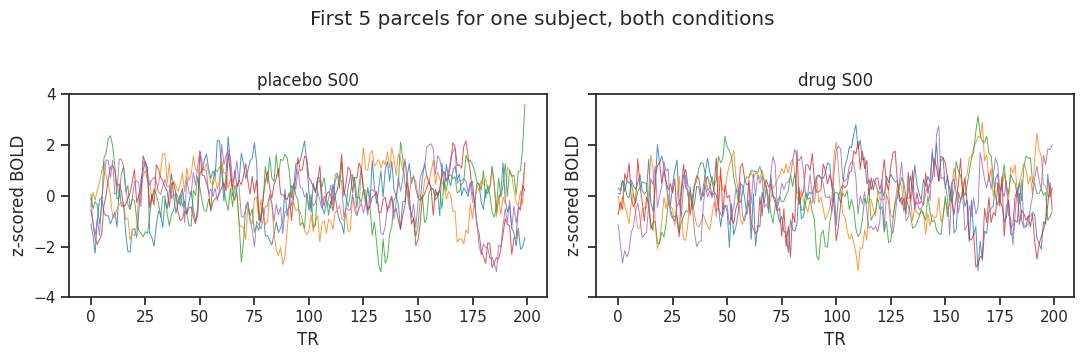

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, ts, title in [(axes[0], ts_pcb['S00'], 'placebo S00'),
                      (axes[1], ts_drug['S00'], 'drug S00')]:
    ax.plot(ts[:, :5], lw=0.7, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('TR')
    ax.set_ylabel('z-scored BOLD')
axes[0].set_ylim(-4, 4)
plt.suptitle('First 5 parcels for one subject, both conditions', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Group-level variance fingerprint: under drug, individual parcels should have
# slightly higher variance because the chaotic component is high-variance.
drug_var = np.mean([ts.var(axis=0).mean() for ts in ts_drug.values()])
pcb_var = np.mean([ts.var(axis=0).mean() for ts in ts_pcb.values()])
print(f"mean parcel variance, drug: {drug_var:.3f}")
print(f"mean parcel variance, pcb : {pcb_var:.3f}")
print('Both are ~1 after standardisation, as expected.')

mean parcel variance, drug: 1.000
mean parcel variance, pcb : 1.000
Both are ~1 after standardisation, as expected.


## 2. Build mock FC gradients

In the original study, gradients come from diffusion embedding of a group-mean functional-connectivity matrix (BrainSpace `GradientMaps`, scale=100, n_components=3). The first three gradients span the canonical *unimodal-to-transmodal*, *visual*, and *task-positive vs. default* axes of cortical organisation (Margulies 2016).

Here we substitute a synthetic gradient basis: the top 3 eigenvectors of a correlation matrix built from random features. The downstream geometry (low-dim manifold the trajectory lives on) is qualitatively similar, while keeping the notebook fully self-contained.

In [6]:
def mock_gradients(n_parcels=100, n_components=3, seed=0):
    """
    Synthetic stand-in for HCP gradients. Real pipeline:
        gm = brainspace.gradient.GradientMaps(n_components=3, random_state=0)
        gm.fit(group_fc_matrix)
        grad_hcp = gm.gradients_
    """
    rng_local = np.random.default_rng(seed)
    base = rng_local.standard_normal((n_parcels, 30))
    fc = np.corrcoef(base)
    w, V = np.linalg.eigh(fc)
    idx = np.argsort(w)[::-1][:n_components]
    return V[:, idx]

gradient matrix shape: (100, 3)  (parcels, components)


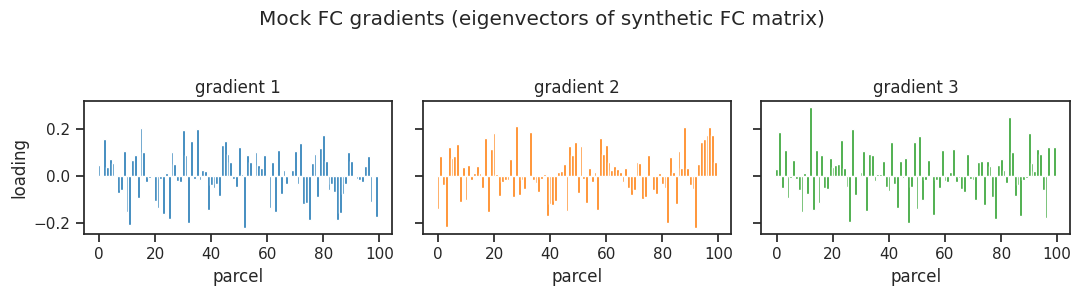

In [7]:
grads = mock_gradients(N_PARCELS, N_GRADIENTS, seed=SEED)
print(f"gradient matrix shape: {grads.shape}  (parcels, components)")

fig, axes = plt.subplots(1, N_GRADIENTS, figsize=(11, 2.8), sharey=True)
for c in range(N_GRADIENTS):
    axes[c].bar(range(N_PARCELS), grads[:, c], width=1.0, color=f'C{c}')
    axes[c].set_title(f'gradient {c+1}')
    axes[c].set_xlabel('parcel')
axes[0].set_ylabel('loading')
plt.suptitle('Mock FC gradients (eigenvectors of synthetic FC matrix)', y=1.05)
plt.tight_layout()
plt.show()

## 3. Project parcel timeseries into gradient space

For each timepoint $t$ and each gradient $c$, compute the Pearson correlation between the parcel-pattern at time $t$ and gradient $c$:

$$g_t^{(c)} = \mathrm{corr}\big(\mathbf{x}_t, \mathbf{v}^{(c)}\big), \quad c=1,2,3$$

This yields a 3D timeseries per subject - the trajectory in *gradient space*. The interpretation: at each TR, how much does the current brain pattern resemble each principal axis of FC organisation? Variation in these coordinates over time *is* the brain-state trajectory.

In [8]:
def project_to_gradients(ts, grads):
    """
    ts:    (T, P)
    grads: (P, n_components)
    Returns (T, n_components) of per-timepoint Pearson correlations.

    Matches the original pipeline's `np.corrcoef(X, b)` with b = grads.T,
    extracting the cross-block of the resulting full corrcoef matrix.
    """
    T, _ = ts.shape
    n_c = grads.shape[1]
    out = np.zeros((T, n_c))
    for t in range(T):
        for c in range(n_c):
            out[t, c] = np.corrcoef(ts[t], grads[:, c])[0, 1]
    return out

In [9]:
corr_drug = {s: project_to_gradients(ts_drug[s], grads) for s in ts_drug}
corr_pcb = {s: project_to_gradients(ts_pcb[s], grads) for s in ts_pcb}
print(f"gradient-space trajectory shape per subject: {corr_drug['S00'].shape}  (T, 3)")

gradient-space trajectory shape per subject: (200, 3)  (T, 3)


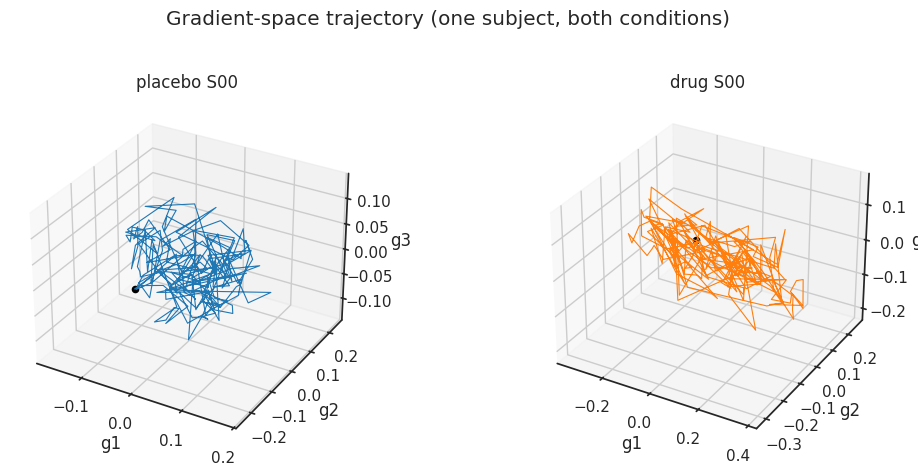

In [10]:
# Visualise one subject's 3D trajectory
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(11, 4.5))
for i, (corr_dict, label) in enumerate([(corr_pcb, 'placebo S00'),
                                         (corr_drug, 'drug S00')]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    traj = corr_dict['S00']
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=0.8, color=f'C{i}')
    ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color='k', s=20, label='start')
    ax.set_title(label)
    ax.set_xlabel('g1'); ax.set_ylabel('g2'); ax.set_zlabel('g3')
plt.suptitle('Gradient-space trajectory (one subject, both conditions)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Reconstruct 6D phase space

A 3D trajectory $g_t \in \mathbb{R}^3$ alone does not specify a unique dynamical state: position and velocity together do. The standard fix is to augment position coordinates with their time derivatives:

$$X_t = \big[g_t,\ \dot g_t\big]\ \in\ \mathbb{R}^6, \qquad \dot g_t \approx g_{t+1} - g_t$$

This is the same idea as Takens delay embedding but using an explicit derivative instead of lagged coordinates (Eckmann & Ruelle 1985 discuss when these are equivalent). The 6D state is what the Lyapunov estimator will operate on in the next notebook.

In [11]:
def build_phase_space(corr_3d):
    """
    Concatenate the 3 gradient correlations with their first time derivative.
    Output shape: (T-1, 6).
    """
    ddt = np.diff(corr_3d, axis=0)
    base = corr_3d[1:]  # align with derivative
    return np.hstack([base, ddt])

In [12]:
phase_drug = {s: build_phase_space(corr_drug[s]) for s in corr_drug}
phase_pcb = {s: build_phase_space(corr_pcb[s]) for s in corr_pcb}
print(f"6D phase-space shape per subject: {phase_drug['S00'].shape}  (T-1, 6)")

6D phase-space shape per subject: (199, 6)  (T-1, 6)


In [13]:
# Quick numerical fingerprint of the 6D state
example = phase_drug['S00']
desc = pd.DataFrame(example, columns=[f'g{i+1}' for i in range(3)] +
                                     [f'dg{i+1}' for i in range(3)]).describe()
print(desc.round(3))

            g1       g2       g3      dg1      dg2      dg3
count  199.000  199.000  199.000  199.000  199.000  199.000
mean     0.012   -0.005   -0.001   -0.001   -0.000    0.000
std      0.156    0.105    0.069    0.115    0.083    0.059
min     -0.342   -0.312   -0.208   -0.355   -0.295   -0.176
25%     -0.100   -0.087   -0.053   -0.073   -0.057   -0.037
50%      0.014   -0.010    0.004    0.014   -0.003    0.002
75%      0.125    0.074    0.048    0.082    0.053    0.034
max      0.381    0.253    0.160    0.280    0.357    0.174


## 5. Save for the next notebook

In [14]:
payload = {
    'phase_drug': phase_drug,
    'phase_pcb': phase_pcb,
    'corr_drug': corr_drug,
    'corr_pcb': corr_pcb,
    'meta': {
        'n_parcels': N_PARCELS, 'n_tr': N_TR, 'n_subj': N_SUBJ,
        'n_gradients': N_GRADIENTS, 'seed': SEED,
        'note': 'Simulated fMRI-like data with Henon-chaos drug effect.'
    }
}
with open(OUT / 'phase_space.pkl', 'wb') as fp:
    pickle.dump(payload, fp)
print(f"saved to {OUT / 'phase_space.pkl'}")

saved to outputs/phase_space.pkl


## Summary

**What this notebook produced.** For each of 15 subjects × 2 conditions:
- a 6D phase-space trajectory of length ~199 timepoints (`phase_drug`, `phase_pcb`)
- the underlying 3D gradient-space trajectory (`corr_drug`, `corr_pcb`)

**Key design decisions.**
- *Simulator vs real fMRI*: the structural pipeline (parcels → gradients → projection → phase space) is identical to the original study; only the input data is synthetic.
- *Drug effect*: implemented via Henon-map injection into latent shared factors. This is a stylised but principled way to operationalise "more chaotic dynamics under psychedelics" - the system has a known positive Lyapunov exponent built in.
- *Mock gradients*: eigenvectors of a synthetic FC matrix substitute for BrainSpace HCP gradients. This avoids a heavy dependency while preserving the geometry of the embedding.

**What the next notebook will do.** Estimate the largest Lyapunov exponent of each subject's 6D trajectory with two methods (split-half nearest-pair vs Rosenstein kNN), compare them on validation data with known $\lambda$, and produce per-subject $\lambda$ values for the group analysis.